In [ ]:
!pip install matplotlib

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
# ----------------------------
# 1. Load dataset
# ----------------------------
df = pd.read_csv("questions_survey.csv")
df.head()


,The platform was easy to learn.,The information is presented in a clear and logical way.,The visualizations effectively represent global HR perspectives on gig work.,I feel comfortable using the platform.,The platform’s user interface was visually appealing and intuitive.,I am satisfied with the features and capabilities of the platform.,My overall impression of the platform is positive.,I would recommend this platform to HR managers managing gig workers.,I would recommend gig workers use this platform.,I am likely to continue using this platform in the future.,...,How useful was each of the following components to your work? - HR Hiring Practices for Gig Work,What gender do you mostly identify with?,What ethnicity do you mostly identify with?,What is your current age in years? Please enter a whole number.,What is the highest level of education you have completed?,Do you have a disability? (Either a physical or cognitive disability),What industry does your company operate in?,How many employees does your company have?,What percentage of your workforce is gig workers?,Will the platform contribute to any improvements in (multiple options are possible)
0,Strongly agree,Strongly agree,Strongly agree,Extremely comfortable,Strongly agree,Extremely satisfied,Extremely positive,Strongly agree,Strongly agree,Somewhat agree,...,Very useful,Male,White/Caucasian/European,52,"Graduate or professional degree (MA, MS, MBA, ...",No,Provision of close protection security and man...,249,11-25%,Data-driven HR decision-making
1,Neither agree nor disagree,Somewhat agree,Somewhat agree,Neither comfortable nor uncomfortable,Somewhat agree,Somewhat satisfied,Extremely positive,Somewhat agree,Somewhat agree,Somewhat agree,...,Extremely useful,Male,Black/Caribbean/African/Afro Latin,30,University - Bachelors Degree,No,Public Administration,200,0-10%,"Inclusion or fairness in hiring,Data-driven HR..."
2,Strongly agree,Strongly agree,Strongly agree,Extremely comfortable,Strongly agree,Extremely satisfied,Extremely positive,Strongly agree,Strongly agree,Strongly agree,...,Extremely useful,Female,Black/Caribbean/African/Afro Latin,57,Some University but no degree,No,Professional Services,11,11-25%,"Inclusion or fairness in hiring,Data-driven HR..."
3,Strongly agree,Strongly agree,Strongly agree,Extremely comfortable,Strongly agree,Extremely satisfied,Extremely positive,Strongly agree,Strongly agree,Strongly agree,...,Extremely useful,Female,Black/Caribbean/African/Afro Latin,35,"Graduate or professional degree (MA, MS, MBA, ...",No,Software engineering,53,26-50%,"Inclusion or fairness in hiring,Data-driven HR..."
4,Strongly agree,Strongly agree,Strongly agree,Extremely comfortable,Strongly agree,Extremely satisfied,Extremely positive,Strongly agree,Strongly agree,Strongly agree,...,Extremely useful,Female,Black/Caribbean/African/Afro Latin,28,Vocational or Similar,No,Catering services,5,76-100%,"Inclusion or fairness in hiring,Data-driven HR..."


In [19]:
# ----------------------------
# 2. Map Likert scale text → numeric
# ----------------------------
likert_map = {
    "Strongly disagree": 1,
    "Somewhat disagree": 2,
    "Neither agree nor disagree": 3,
    "Somewhat agree": 4,
    "Strongly agree": 5,
    "Extremely uncomfortable": 1,
    "Somewhat uncomfortable": 2,
    "Neither comfortable nor uncomfortable": 3,
    "Somewhat comfortable": 4,
    "Extremely comfortable": 5,
    "Extremely negative": 1,
    "Somewhat negative": 2,
    "Somewhat positive": 4,
    "Extremely positive": 5,
    "Not at all useful": 1,
    "Slightly useful": 2,
    "Moderately useful": 3,
    "Very useful": 4,
    "Extremely useful": 5,
    "Extremely unsatisfied": 1,
    "Somewhat unsatisfied": 2,
    "Somewhat satisfied": 3,
    "Extremely satisfied": 5,
}

df_stats = df.replace(likert_map)

/tmp/ipykernel_341470/4129757471.py:30: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_stats = df.replace(likert_map)


In [20]:
df_stats.head()

,The platform was easy to learn.,The information is presented in a clear and logical way.,The visualizations effectively represent global HR perspectives on gig work.,I feel comfortable using the platform.,The platform’s user interface was visually appealing and intuitive.,I am satisfied with the features and capabilities of the platform.,My overall impression of the platform is positive.,I would recommend this platform to HR managers managing gig workers.,I would recommend gig workers use this platform.,I am likely to continue using this platform in the future.,...,How useful was each of the following components to your work? - HR Hiring Practices for Gig Work,What gender do you mostly identify with?,What ethnicity do you mostly identify with?,What is your current age in years? Please enter a whole number.,What is the highest level of education you have completed?,Do you have a disability? (Either a physical or cognitive disability),What industry does your company operate in?,How many employees does your company have?,What percentage of your workforce is gig workers?,Will the platform contribute to any improvements in (multiple options are possible)
0,5,5,5,5,5,5,5,5,5,4,...,4,Male,White/Caucasian/European,52,"Graduate or professional degree (MA, MS, MBA, ...",No,Provision of close protection security and man...,249,11-25%,Data-driven HR decision-making
1,3,4,4,3,4,3,5,4,4,4,...,5,Male,Black/Caribbean/African/Afro Latin,30,University - Bachelors Degree,No,Public Administration,200,0-10%,"Inclusion or fairness in hiring,Data-driven HR..."
2,5,5,5,5,5,5,5,5,5,5,...,5,Female,Black/Caribbean/African/Afro Latin,57,Some University but no degree,No,Professional Services,11,11-25%,"Inclusion or fairness in hiring,Data-driven HR..."
3,5,5,5,5,5,5,5,5,5,5,...,5,Female,Black/Caribbean/African/Afro Latin,35,"Graduate or professional degree (MA, MS, MBA, ...",No,Software engineering,53,26-50%,"Inclusion or fairness in hiring,Data-driven HR..."
4,5,5,5,5,5,5,5,5,5,5,...,5,Female,Black/Caribbean/African/Afro Latin,28,Vocational or Similar,No,Catering services,5,76-100%,"Inclusion or fairness in hiring,Data-driven HR..."


In [25]:
df_num = df_stats.iloc[:, 0:14]
df_num.head()

,The platform was easy to learn.,The information is presented in a clear and logical way.,The visualizations effectively represent global HR perspectives on gig work.,I feel comfortable using the platform.,The platform’s user interface was visually appealing and intuitive.,I am satisfied with the features and capabilities of the platform.,My overall impression of the platform is positive.,I would recommend this platform to HR managers managing gig workers.,I would recommend gig workers use this platform.,I am likely to continue using this platform in the future.,How useful was each of the following components to your work? - Global HR Compass,How useful was each of the following components to your work? - Impact Metrics Hub,How useful was each of the following components to your work? - HR Voices and Sentiments,How useful was each of the following components to your work? - HR Hiring Practices for Gig Work
0,5,5,5,5,5,5,5,5,5,4,4,5,4,4
1,3,4,4,3,4,3,5,4,4,4,5,5,5,5
2,5,5,5,5,5,5,5,5,5,5,2,5,5,5
3,5,5,5,5,5,5,5,5,5,5,5,4,5,5
4,5,5,5,5,5,5,5,5,5,5,5,5,5,5


In [26]:

# ----------------------------
# 3. Descriptive Statistics
# ----------------------------
desc_stats = df_num.agg(['mean', 'median', 'std']).T
print("Descriptive Statistics:\n", desc_stats)

Descriptive Statistics:
                                                         mean  median       std
The platform was easy to learn.                     4.166667     5.0  1.267304
The information is presented in a clear and log...  4.416667     5.0  1.164500
The visualizations effectively represent global...  4.416667     5.0  1.164500
I feel comfortable using the platform.              4.416667     5.0  1.240112
The platform’s user interface was visually appe...  4.750000     5.0  0.452267
I am satisfied with the features and capabiliti...  4.333333     5.0  0.984732
My overall impression of the platform is positive.  4.916667     5.0  0.288675
I would recommend this platform to HR managers ...  4.833333     5.0  0.389249
I would recommend gig workers use this platform.    4.416667     5.0  1.164500
I am likely to continue using this platform in ...  4.583333     5.0  0.514929
How useful was each of the following components...  4.333333     4.5  0.887625
How useful was each of the 

In [27]:

# ----------------------------
# 4. Frequency Counts (per question)
# ----------------------------
counts = df_num.apply(pd.Series.value_counts).fillna(0).astype(int)
print("\nResponse Counts:\n", counts)


Response Counts:
    The platform was easy to learn.  \
1                                1   
2                                0   
3                                2   
4                                2   
5                                7   

   The information is presented in a clear and logical way.  \
1                                                  1          
2                                                  0          
3                                                  0          
4                                                  3          
5                                                  8          

   The visualizations effectively represent global HR perspectives on gig work.  \
1                                                  1                              
2                                                  0                              
3                                                  0                              
4                                        

/tmp/ipykernel_341470/2799964242.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 1200x600 with 0 Axes>

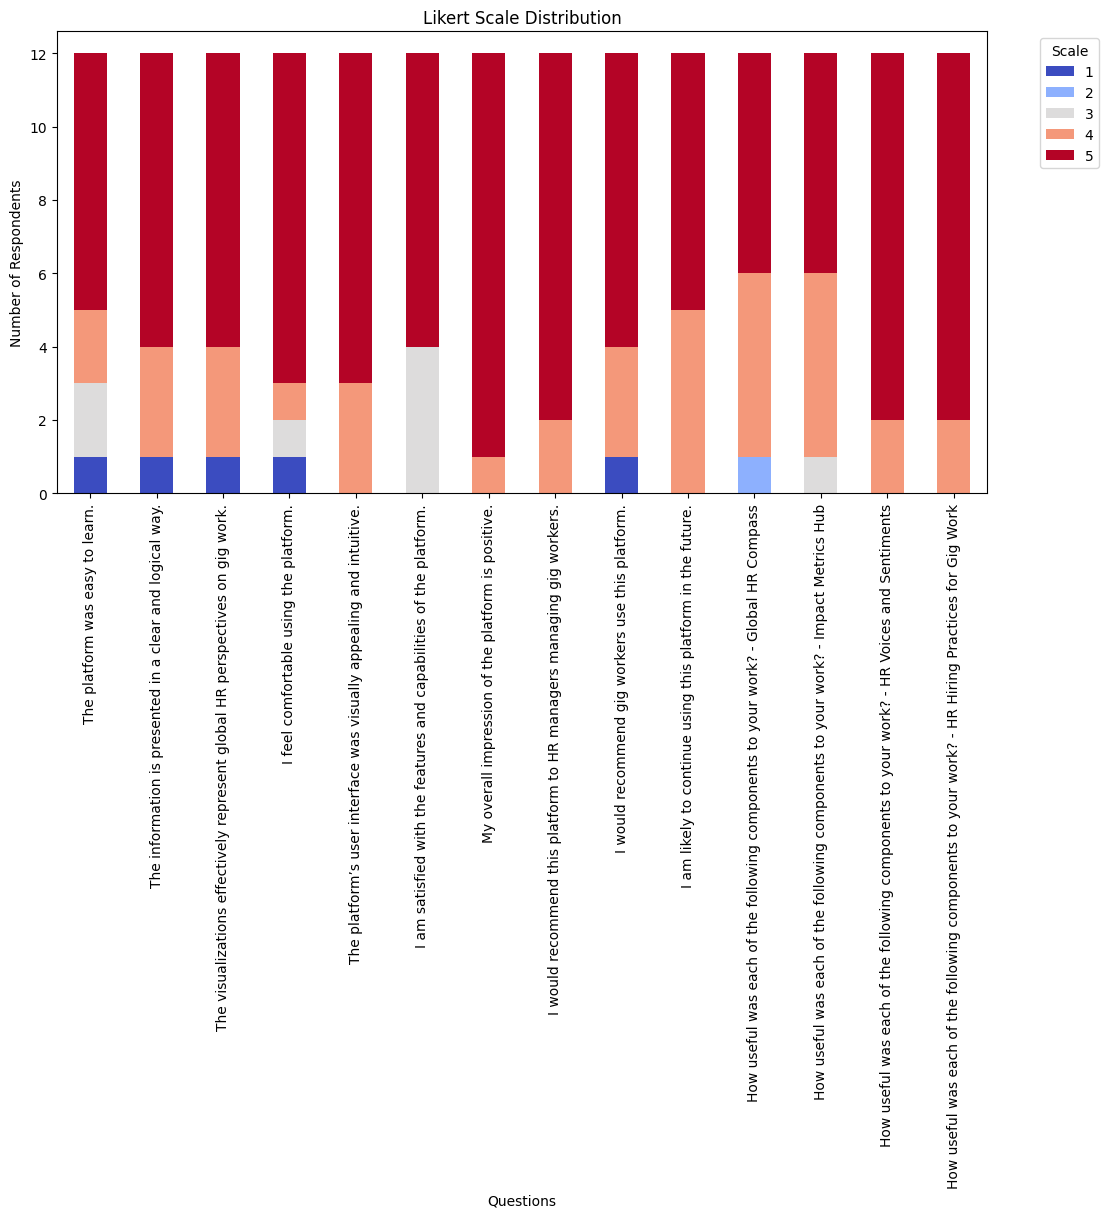

In [28]:
# ----------------------------
# 5. Visualization: Stacked Bar Plot
# ----------------------------
plt.figure(figsize=(12, 6))
counts.T.plot(kind='bar', stacked=True, colormap='coolwarm', figsize=(12, 6))
plt.xlabel('Questions')
plt.ylabel('Number of Respondents')
plt.title('Likert Scale Distribution')
plt.legend(title='Scale', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [29]:

# ----------------------------
# 6. Reliability: Cronbach’s Alpha
# ----------------------------
def cronbach_alpha(df_subset):
    df_corr = df_subset.corr()
    n_items = len(df_subset.columns)
    mean_corr = df_corr.where(np.triu(np.ones(df_corr.shape), k=1).astype(bool)).mean().mean()
    return (n_items * mean_corr) / (1 + (n_items - 1) * mean_corr)

alpha = cronbach_alpha(df_num)
print(f"\nCronbach's Alpha: {alpha:.2f}")


Cronbach's Alpha: 0.85


In [30]:

# ----------------------------
# 7. Correlation Between Questions
# ----------------------------
correlation_matrix = df_num.corr()
print("\nCorrelation Matrix:\n", correlation_matrix)


Correlation Matrix:
                                                     The platform was easy to learn.  \
The platform was easy to learn.                                            1.000000   
The information is presented in a clear and log...                         0.872679   
The visualizations effectively represent global...                         0.872679   
I feel comfortable using the platform.                                     0.877315   
The platform’s user interface was visually appe...                         0.079305   
I am satisfied with the features and capabiliti...                         0.242821   
My overall impression of the platform is positive.                         0.289910   
I would recommend this platform to HR managers ...                         0.061430   
I would recommend gig workers use this platform.                           0.133469   
I am likely to continue using this platform in ...                         0.534018   
How useful was each o

In [31]:
# ----------------------------
# 8. Export results
# ----------------------------
desc_stats.to_csv("likert_summary.csv")
counts.to_csv("likert_counts.csv")
correlation_matrix.to_csv("likert_correlations.csv")
with open("cronbach_alpha.txt", "w") as f:
    f.write(f"Cronbach's Alpha: {alpha:.2f}\n")
